# Motion Sensor Classification using ANN

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

In [2]:
train_df = pd.read_csv("train_motion_data.csv")
test_df = pd.read_csv("test_motion_data.csv")

In [3]:
if "Timestamp" in train_df.columns:
    train_df = train_df.drop("Timestamp", axis=1)
if "Timestamp" in test_df.columns:
    test_df = test_df.drop("Timestamp", axis=1)

In [4]:
x_train = train_df.drop("Class", axis=1).values
y_train_raw = train_df["Class"].values

In [5]:
x_test = test_df.drop("Class", axis=1).values
y_test_raw = test_df["Class"].values

In [6]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train_raw)
y_test = encoder.transform(y_test_raw)

In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model = models.Sequential(
    [
        layers.Input(shape=(x_train.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),  
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(
            len(np.unique(y_train)), activation="softmax"
        ),  
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [9]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

In [10]:
history = model.fit(
    x_train,y_train,epochs=60,batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4175 - loss: 1.0495 - val_accuracy: 0.0000e+00 - val_loss: 1.4962
Epoch 2/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4518 - loss: 1.0357 - val_accuracy: 0.0000e+00 - val_loss: 1.5244
Epoch 3/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4631 - loss: 1.0214 - val_accuracy: 0.0000e+00 - val_loss: 1.4961
Epoch 4/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4820 - loss: 1.0185 - val_accuracy: 0.0000e+00 - val_loss: 1.4213
Epoch 5/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4864 - loss: 1.0111 - val_accuracy: 0.0000e+00 - val_loss: 1.5073
Epoch 6/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4991 - loss: 1.0037 - val_accuracy: 0.0000e+00 - val_loss: 1.5164
Epoch 7/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4971 - loss: 1.0026 - val_accuracy: 0.0000e+00 - val_loss: 1.5182
Epoch 8/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4974 - loss: 1.0004 - val

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

In [12]:
test_loss

1.1165237426757812

In [13]:
test_acc

0.35667964816093445

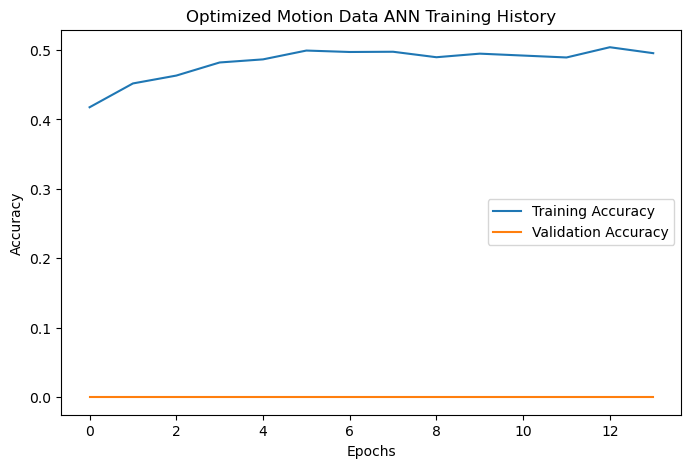

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Optimized Motion Data ANN Training History")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
model.save("motion_ann_model_optimized.h5")